In [1]:
#K Means clustering
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import pandas as pd
%matplotlib inline

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2,)

In [3]:
X

array([[-0.76214929,  4.27175955],
       [-0.08022059,  2.67951347],
       [ 5.58226075,  6.9472447 ],
       ...,
       [ 6.98208729,  6.40684493],
       [ 5.52599581,  6.40491224],
       [ 6.33828367,  6.00915718]], shape=(1000, 2))

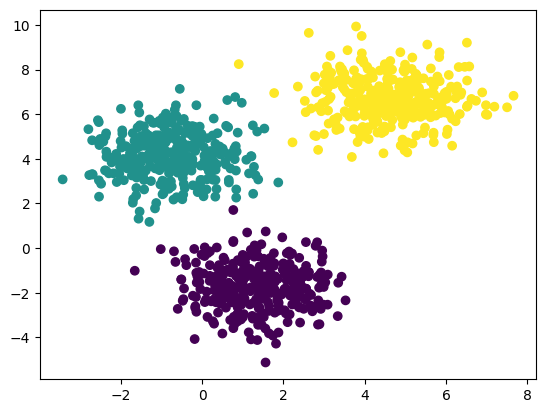

In [4]:
plt.scatter(X[:,0], X[:,1], c=y)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train_scaled = scaler.fit_transform(X_train)

In [9]:
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans



In [11]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

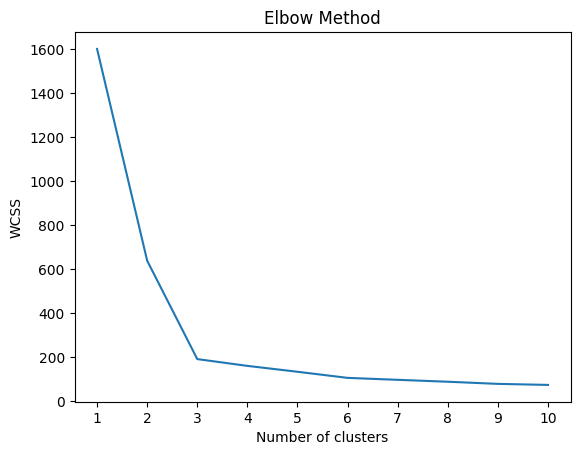

In [15]:
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, init='k-means++')
kmeans.fit_predict(X_train_scaled)

array([0, 1, 2, 0, 0, 0, 1, 0, 2, 2, 0, 1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 0,
       0, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0,
       1, 1, 2, 2, 1, 2, 1, 0, 1, 0, 2, 0, 2, 1, 1, 1, 0, 0, 1, 1, 0, 2,
       0, 2, 0, 0, 1, 1, 0, 0, 2, 1, 1, 0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 2,
       2, 1, 0, 0, 1, 1, 1, 2, 1, 1, 0, 2, 1, 2, 1, 2, 1, 0, 0, 0, 2, 0,
       0, 0, 0, 2, 0, 1, 0, 2, 0, 1, 1, 1, 2, 1, 2, 1, 1, 2, 2, 1, 2, 2,
       0, 1, 0, 1, 2, 1, 2, 1, 2, 0, 1, 2, 1, 1, 2, 2, 0, 0, 2, 2, 0, 0,
       1, 0, 1, 0, 0, 2, 0, 2, 1, 0, 1, 0, 1, 2, 1, 1, 0, 2, 2, 0, 2, 0,
       1, 0, 2, 2, 2, 1, 1, 0, 1, 1, 1, 0, 0, 2, 2, 1, 2, 0, 2, 1, 2, 1,
       1, 1, 0, 1, 1, 2, 0, 2, 0, 2, 2, 0, 1, 2, 2, 2, 1, 0, 1, 2, 1, 2,
       1, 1, 2, 1, 1, 2, 0, 2, 2, 2, 1, 0, 1, 0, 1, 1, 2, 0, 2, 0, 1, 0,
       2, 2, 2, 2, 1, 0, 2, 2, 1, 0, 0, 0, 2, 0, 2, 1, 0, 2, 0, 2, 1, 0,
       2, 0, 1, 1, 1, 2, 0, 1, 0, 2, 1, 0, 1, 2, 0, 1, 0, 0, 2, 0, 0, 0,
       1, 0, 0, 2, 2, 1, 2, 0, 1, 0, 0, 2, 1, 0, 0,

In [17]:
y_pred = kmeans.predict(X_test_scaled)

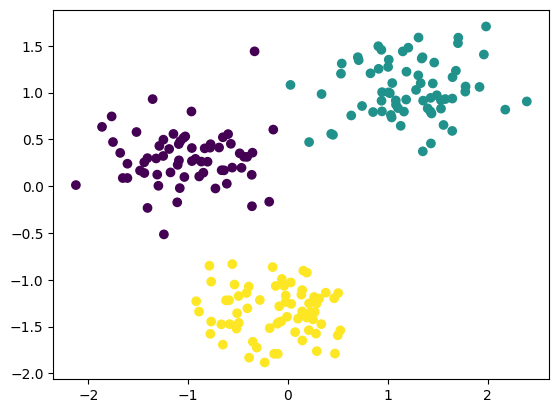

In [18]:
plt.scatter(X_test_scaled[:,0], X_test_scaled[:,1], c=y_pred)

In [19]:
!pip install kneed

In [20]:
from kneed import KneeLocator
knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
knee.elbow

np.int64(3)

In [21]:
from sklearn.metrics import silhouette_score
silhouette_coefficient = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficient.append(score)

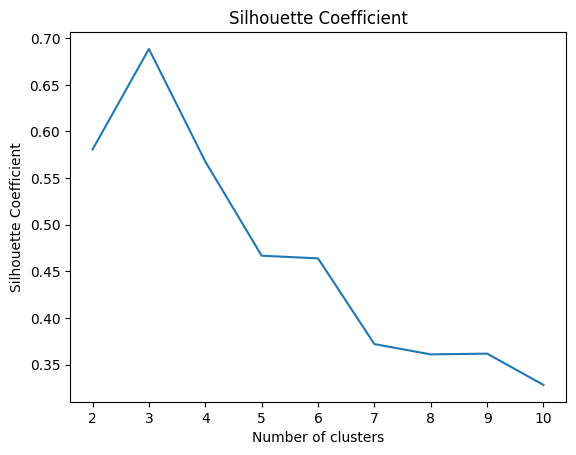

In [23]:
plt.plot(range(2, 11), silhouette_coefficient)
plt.xticks(range(2, 11))
plt.title('Silhouette Coefficient')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()